# NYC Yellow Taxi Data Understanding (Q1 2025)

This notebook examines the final analysis-ready NYC Yellow Taxi dataset before model building.

## 1. Import Libraries and Load the Dataset

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import pearsonr, spearmanr

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_FILE = Path("nyc_yellow_taxi_master_analysis_ready_2025_q1.csv")
if not DATA_FILE.exists():
    DATA_FILE = Path("/mnt/data/nyc_yellow_taxi_master_analysis_ready_2025_q1.csv")

df = pd.read_csv(DATA_FILE)
df["pickup_hour"] = pd.to_datetime(df["pickup_hour"])

display(df.head())

,LocationID,borough,zone,service_zone,pickup_hour,hour,day_of_week,month,pickup_count,temperature_f,precipitation_in,subway_proximity_km,estimated_total_households,estimated_zero_vehicle_households,zero_vehicle_household_rate,zero_vehicle_rate_moe,zero_vehicle_rate_cv,census_reliability,census_coverage_ratio
0,2,Queens,Jamaica Bay,Boro Zone,2025-01-01 00:00:00,0,2,1,0,44.9600,0.0000,1.5986,17.7722,2.1082,0.1186,1.1062,5.6696,low,1.0000
1,2,Queens,Jamaica Bay,Boro Zone,2025-01-01 01:00:00,1,2,1,0,44.9600,0.0000,1.5986,17.7722,2.1082,0.1186,1.1062,5.6696,low,1.0000
2,2,Queens,Jamaica Bay,Boro Zone,2025-01-01 02:00:00,2,2,1,0,44.9600,0.0000,1.5986,17.7722,2.1082,0.1186,1.1062,5.6696,low,1.0000
3,2,Queens,Jamaica Bay,Boro Zone,2025-01-01 03:00:00,3,2,1,0,46.9400,0.0000,1.5986,17.7722,2.1082,0.1186,1.1062,5.6696,low,1.0000
4,2,Queens,Jamaica Bay,Boro Zone,2025-01-01 04:00:00,4,2,1,0,48.0200,0.0000,1.5986,17.7722,2.1082,0.1186,1.1062,5.6696,low,1.0000


**Interpretation:** The analysis-ready master dataset is loaded with the hourly taxi demand, temporal variables, weather variables, spatial identifiers, contextual features, and Census quality fields required for Data Understanding.

## 2. Dataset Observations

In [2]:
zone_counts = df.groupby("LocationID").size()

observation_summary = pd.DataFrame({
    "Measure": [
        "Rows",
        "Columns",
        "Taxi zones",
        "Unique hourly timestamps",
        "Study start",
        "Study end",
        "Rows per zone - minimum",
        "Rows per zone - maximum",
        "Duplicate zone-hour records",
        "Missing cells"
    ],
    "Result": [
        len(df),
        df.shape[1],
        df["LocationID"].nunique(),
        df["pickup_hour"].nunique(),
        df["pickup_hour"].min(),
        df["pickup_hour"].max(),
        zone_counts.min(),
        zone_counts.max(),
        df.duplicated(["LocationID", "pickup_hour"]).sum(),
        df.isna().sum().sum()
    ]
})

display(observation_summary)

,Measure,Result
0,Rows,559181
1,Columns,19
2,Taxi zones,259
3,Unique hourly timestamps,2159
4,Study start,2025-01-01 00:00:00
5,Study end,2025-03-31 23:00:00
6,Rows per zone - minimum,2159
7,Rows per zone - maximum,2159
8,Duplicate zone-hour records,0
9,Missing cells,0


**Interpretation:** Each modelling observation represents one taxi zone at one hourly timestamp. Taxi-demand analysis therefore uses zone-hour rows, weather summaries use one record per unique hour, and static contextual variables are examined once per taxi zone.

## 3. Hourly Taxi Demand Distribution

In [3]:
pickups = df["pickup_count"]

target_statistics = pd.DataFrame({
    "Statistic": [
        "Total pickups",
        "Mean",
        "Standard deviation",
        "Minimum",
        "25th percentile",
        "Median",
        "75th percentile",
        "90th percentile",
        "95th percentile",
        "99th percentile",
        "Maximum",
        "Skewness",
        "Zero-demand zone-hours",
        "Zero-demand zone-hours (%)"
    ],
    "Value": [
        pickups.sum(),
        pickups.mean(),
        pickups.std(),
        pickups.min(),
        pickups.quantile(0.25),
        pickups.quantile(0.50),
        pickups.quantile(0.75),
        pickups.quantile(0.90),
        pickups.quantile(0.95),
        pickups.quantile(0.99),
        pickups.max(),
        pickups.skew(),
        pickups.eq(0).sum(),
        pickups.eq(0).mean() * 100
    ]
})

display(target_statistics)

zero_demand_zones = (
    df.groupby(["LocationID", "borough", "zone"], as_index=False)["pickup_count"]
      .sum()
      .query("pickup_count == 0")
)

display(zero_demand_zones)

,Statistic,Value
0,Total pickups,"10,218,621.0000"
1,Mean,18.2743
2,Standard deviation,54.8751
3,Minimum,0.0000
4,25th percentile,0.0000
5,Median,1.0000
6,75th percentile,4.0000
7,90th percentile,52.0000
8,95th percentile,124.0000
9,99th percentile,279.0000


,LocationID,borough,zone,pickup_count
42,44,Staten Island,Charleston/Tottenville,0
105,110,Staten Island,Great Kills Park,0


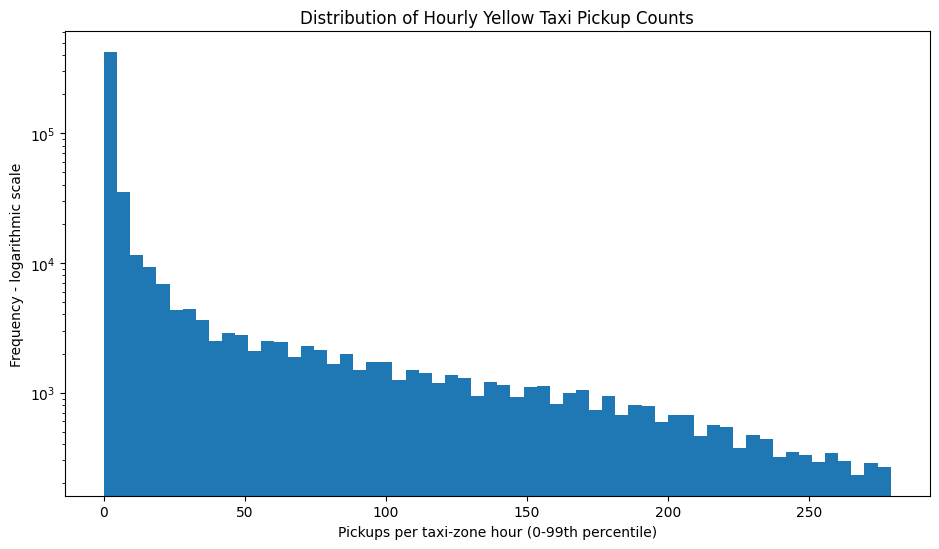

In [4]:
upper_99 = pickups.quantile(0.99)

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.hist(df.loc[pickups <= upper_99, "pickup_count"], bins=60)
ax.set_yscale("log")
ax.set_xlabel("Pickups per taxi-zone hour (0-99th percentile)")
ax.set_ylabel("Frequency - logarithmic scale")
ax.set_title("Distribution of Hourly Yellow Taxi Pickup Counts")
plt.tight_layout()
plt.show()

**Interpretation:** The target is strongly right-skewed, with a large concentration of zero and very low pickup counts together with a much smaller high-demand tail.

## 4. Temporal Taxi Demand Patterns

### 4.1 Demand by Hour of Day

In [5]:
hour_summary = (
    df.groupby("hour")["pickup_count"]
      .agg(mean_pickups="mean", median_pickups="median", total_pickups="sum")
      .reset_index()
)

display(hour_summary)

hour_extremes = pd.DataFrame({
    "Measure": ["Lowest mean-demand hour", "Highest mean-demand hour"],
    "Hour": [
        int(hour_summary.loc[hour_summary["mean_pickups"].idxmin(), "hour"]),
        int(hour_summary.loc[hour_summary["mean_pickups"].idxmax(), "hour"])
    ],
    "Mean pickups": [
        hour_summary["mean_pickups"].min(),
        hour_summary["mean_pickups"].max()
    ]
})

display(hour_extremes)

,hour,mean_pickups,median_pickups,total_pickups
0,0,13.1472,0.0000,306462
1,1,8.7427,0.0000,203792
2,2,5.6770,0.0000,130860
3,3,3.8986,0.0000,90876
4,4,2.8964,0.0000,67515
5,5,3.0470,1.0000,71025
6,6,6.2982,1.0000,146812
7,7,12.5066,2.0000,291529
8,8,17.4084,2.0000,405789
9,9,18.1105,1.0000,422155


,Measure,Hour,Mean pickups
0,Lowest mean-demand hour,4,2.8964
1,Highest mean-demand hour,18,31.2380


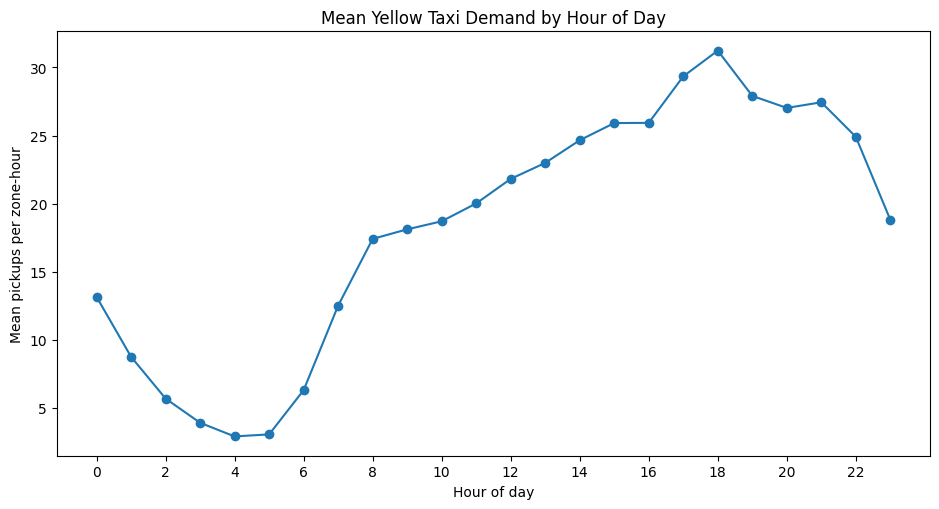

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(hour_summary["hour"], hour_summary["mean_pickups"], marker="o")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean pickups per zone-hour")
ax.set_title("Mean Yellow Taxi Demand by Hour of Day")
plt.tight_layout()
plt.show()

**Interpretation:** Taxi demand follows a clear daily cycle, falling to its lowest level in the early morning and reaching its strongest average level during the evening period.

### 4.2 Demand by Day of Week

In [7]:
day_labels = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

day_summary = (
    df.groupby("day_of_week")["pickup_count"]
      .agg(mean_pickups="mean", median_pickups="median", total_pickups="sum")
      .reindex(range(7))
      .reset_index()
)
day_summary["day"] = day_summary["day_of_week"].map(day_labels)

display(day_summary[["day_of_week", "day", "mean_pickups", "median_pickups", "total_pickups"]])

hour_day = (
    df.groupby(["day_of_week", "hour"])["pickup_count"]
      .mean()
      .unstack("hour")
      .reindex(range(7))
)

hour_day_long = hour_day.stack().rename("mean_pickups").reset_index()
highest_day_hour = hour_day_long.loc[hour_day_long["mean_pickups"].idxmax()].copy()
lowest_day_hour = hour_day_long.loc[hour_day_long["mean_pickups"].idxmin()].copy()

hour_day_extremes = pd.DataFrame({
    "Measure": ["Lowest day-hour combination", "Highest day-hour combination"],
    "Day": [day_labels[int(lowest_day_hour["day_of_week"])], day_labels[int(highest_day_hour["day_of_week"])]],
    "Hour": [int(lowest_day_hour["hour"]), int(highest_day_hour["hour"])],
    "Mean pickups": [lowest_day_hour["mean_pickups"], highest_day_hour["mean_pickups"]]
})

display(hour_day_extremes)

,day_of_week,day,mean_pickups,median_pickups,total_pickups
0,0,Monday,14.9533,1.0000,1208350
1,1,Tuesday,17.5566,1.0000,1309582
2,2,Wednesday,18.3981,1.0000,1486716
3,3,Thursday,19.8692,1.0000,1605594
4,4,Friday,19.1978,1.0000,1551333
5,5,Saturday,20.8793,1.0000,1687215
6,6,Sunday,17.0062,1.0000,1369831


,Measure,Day,Hour,Mean pickups
0,Lowest day-hour combination,Tuesday,3,0.7526
1,Highest day-hour combination,Saturday,19,35.7259


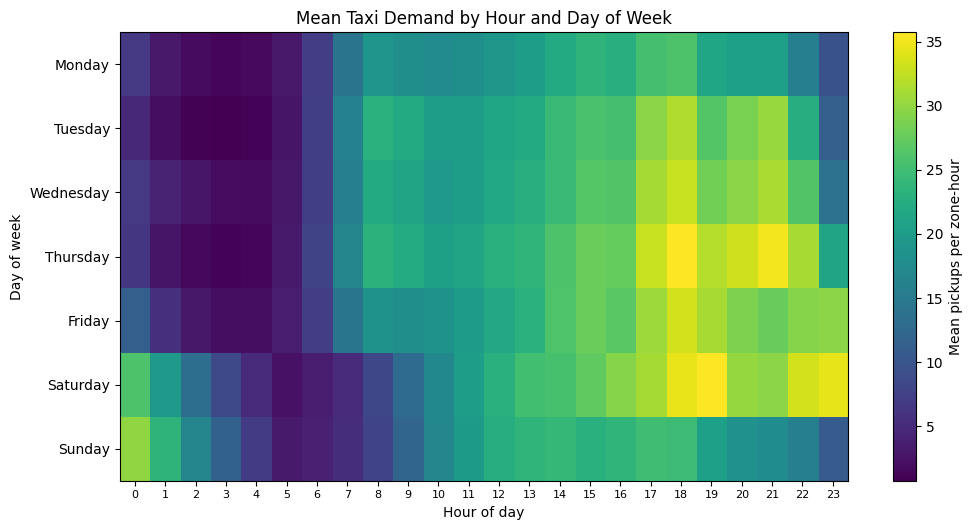

In [8]:
fig, ax = plt.subplots(figsize=(10.5, 5.4))
im = ax.imshow(hour_day.values, aspect="auto")
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=8)
ax.set_yticks(range(7))
ax.set_yticklabels([day_labels[i] for i in range(7)])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
ax.set_title("Mean Taxi Demand by Hour and Day of Week")
fig.colorbar(im, ax=ax, label="Mean pickups per zone-hour")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap shows that the hourly demand cycle changes across the week, with stronger late-afternoon and evening activity on several days and different weekend behaviour.

### 4.3 Demand by Month

In [9]:
month_labels = {1: "January", 2: "February", 3: "March"}

month_summary = (
    df.groupby("month")["pickup_count"]
      .agg(mean_pickups="mean", median_pickups="median", total_pickups="sum")
      .reset_index()
)
month_summary["month_name"] = month_summary["month"].map(month_labels)

display(month_summary[["month", "month_name", "mean_pickups", "median_pickups", "total_pickups"]])

,month,month_name,mean_pickups,median_pickups,total_pickups
0,1,January,16.5773,0.0000,3194374
1,2,February,18.7004,1.0000,3254763
2,3,March,19.5881,1.0000,3769484


**Interpretation:** The three months provide the model with the temporal position within Q1 2025, but they are not sufficient to represent a complete annual seasonal pattern.

## 5. Spatial Variation in Taxi Demand

### 5.1 Demand by Borough

In [10]:
borough_summary = (
    df.groupby("borough")
      .agg(
          taxi_zones=("LocationID", "nunique"),
          total_pickups=("pickup_count", "sum"),
          mean_zone_hour_demand=("pickup_count", "mean"),
          median_zone_hour_demand=("pickup_count", "median")
      )
      .sort_values("total_pickups", ascending=False)
)
borough_summary["pickup_share_percent"] = (
    borough_summary["total_pickups"] / borough_summary["total_pickups"].sum() * 100
)

display(borough_summary.reset_index())

,borough,taxi_zones,total_pickups,mean_zone_hour_demand,median_zone_hour_demand,pickup_share_percent
0,Manhattan,66,9055323,63.5488,24.0000,88.6159
1,Queens,69,846034,5.6792,0.0000,8.2793
2,Brooklyn,61,253825,1.9273,1.0000,2.4839
3,Bronx,43,62677,0.6751,0.0000,0.6134
4,Staten Island,20,762,0.0176,0.0000,0.0075


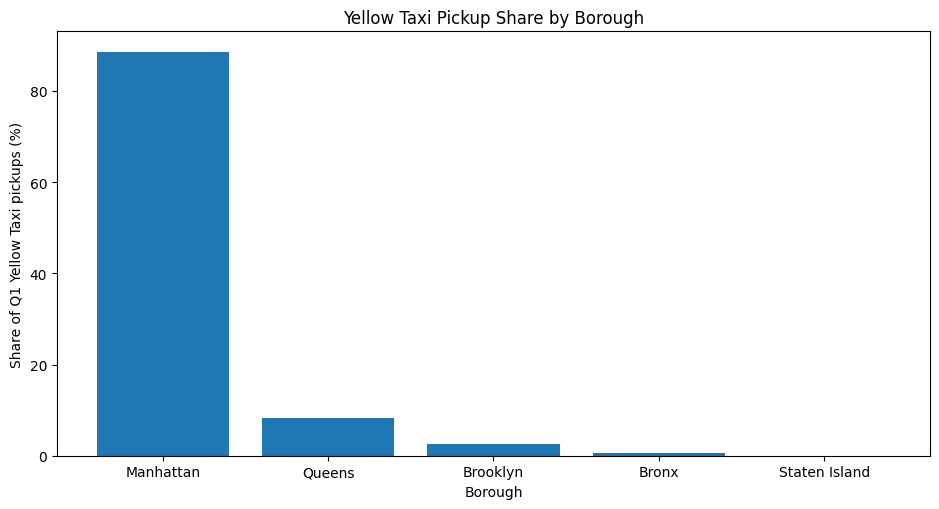

In [11]:
plot_borough = borough_summary.reset_index()

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.bar(plot_borough["borough"], plot_borough["pickup_share_percent"])
ax.set_xlabel("Borough")
ax.set_ylabel("Share of Q1 Yellow Taxi pickups (%)")
ax.set_title("Yellow Taxi Pickup Share by Borough")
plt.tight_layout()
plt.show()

**Interpretation:** Yellow Taxi demand is highly concentrated in Manhattan, showing why aggregate citywide model metrics can be dominated by a relatively small spatial part of the study area.

### 5.2 Demand by Taxi Zone

In [12]:
zone_summary = (
    df.groupby(["LocationID", "borough", "zone"], as_index=False)["pickup_count"]
      .agg(mean_hourly_demand="mean", median_hourly_demand="median", total_pickups="sum")
)

zone_distribution = zone_summary["mean_hourly_demand"].describe(percentiles=[0.25, 0.50, 0.75, 0.90]).to_frame("mean_hourly_demand")
display(zone_distribution)

display(zone_summary.sort_values("mean_hourly_demand", ascending=False).head(10))

borough_zone_median = (
    zone_summary.groupby("borough")["mean_hourly_demand"]
                .median()
                .rename("median_zone_mean_hourly_demand")
                .sort_values(ascending=False)
                .reset_index()
)
display(borough_zone_median)

,mean_hourly_demand
count,259.0000
mean,18.2743
std,41.5754
min,0.0000
25%,0.3645
50%,1.0574
75%,5.2110
90%,75.8264
max,221.8509


,LocationID,borough,zone,mean_hourly_demand,median_hourly_demand,total_pickups
156,161,Manhattan,Midtown Center,221.8509,196.0000,478976
232,237,Manhattan,Upper East Side South,215.8170,233.0000,465949
231,236,Manhattan,Upper East Side North,199.4317,207.0000,430573
127,132,Queens,JFK Airport,175.1941,156.0000,378244
225,230,Manhattan,Times Sq/Theatre District,160.0824,147.0000,345618
181,186,Manhattan,Penn Station/Madison Sq West,158.8513,174.0000,342960
157,162,Manhattan,Midtown East,156.7314,150.0000,338383
137,142,Manhattan,Lincoln Square East,144.0750,159.0000,311058
229,234,Manhattan,Union Sq,134.4044,127.0000,290179
165,170,Manhattan,Murray Hill,129.5929,141.0000,279791


,borough,median_zone_mean_hourly_demand
0,Manhattan,52.6582
1,Brooklyn,1.3001
2,Queens,0.7017
3,Bronx,0.6359
4,Staten Island,0.0086


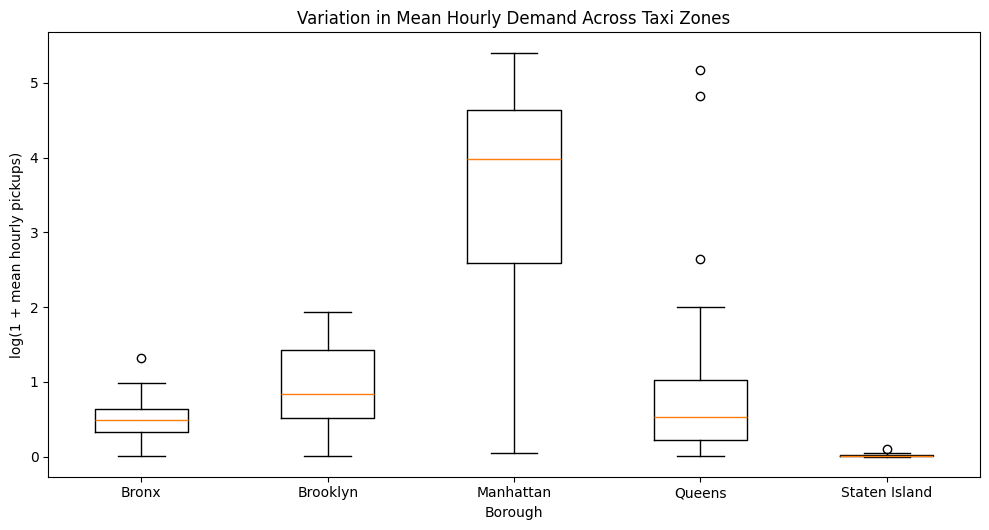

In [13]:
borough_order = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
box_data = [
    np.log1p(zone_summary.loc[zone_summary["borough"] == borough, "mean_hourly_demand"].values)
    for borough in borough_order
]

fig, ax = plt.subplots(figsize=(10.0, 5.4))
ax.boxplot(box_data, tick_labels=borough_order, showfliers=True)
ax.set_xlabel("Borough")
ax.set_ylabel("log(1 + mean hourly pickups)")
ax.set_title("Variation in Mean Hourly Demand Across Taxi Zones")
plt.tight_layout()
plt.show()

**Interpretation:** Large differences exist both between boroughs and between zones within the same borough. This supports evaluating model performance separately for individual taxi zones.

## 6. Weather Characteristics and Taxi Demand

Weather summaries are calculated from one observation per unique hourly timestamp because the same citywide weather value is repeated across all taxi zones for each hour.

### 6.1 Temperature

In [14]:
weather = (
    df[["pickup_hour", "temperature_f", "precipitation_in"]]
      .drop_duplicates("pickup_hour")
      .sort_values("pickup_hour")
)

temperature_statistics = weather["temperature_f"].describe().to_frame("temperature_f")
display(temperature_statistics)

,temperature_f
count,"2,159.0000"
mean,37.8054
std,10.8557
min,10.9400
25%,30.0200
50%,37.0400
75%,46.0400
max,80.9600


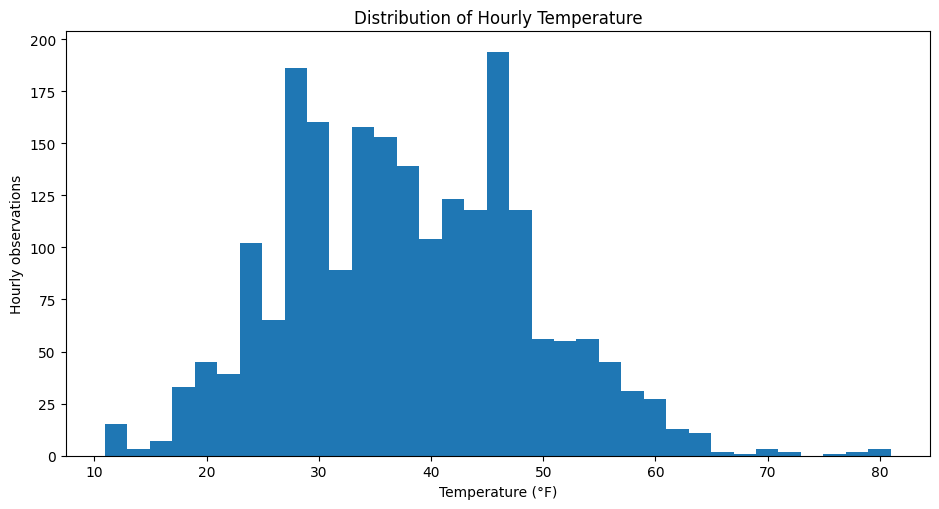

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.hist(weather["temperature_f"], bins=35)
ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Hourly observations")
ax.set_title("Distribution of Hourly Temperature")
plt.tight_layout()
plt.show()

**Interpretation:** Temperature provides continuous hourly variation across the Q1 study period, although the observed range mainly represents winter and early-spring conditions.

### 6.2 Precipitation

In [16]:
precipitation_summary = pd.DataFrame({
    "Measure": [
        "Unique hourly observations",
        "No-precipitation hours",
        "No-precipitation hours (%)",
        "Positive-precipitation hours",
        "Positive-precipitation hours (%)",
        "Mean precipitation",
        "Median precipitation",
        "Median positive precipitation",
        "Maximum precipitation"
    ],
    "Value": [
        len(weather),
        weather["precipitation_in"].eq(0).sum(),
        weather["precipitation_in"].eq(0).mean() * 100,
        weather["precipitation_in"].gt(0).sum(),
        weather["precipitation_in"].gt(0).mean() * 100,
        weather["precipitation_in"].mean(),
        weather["precipitation_in"].median(),
        weather.loc[weather["precipitation_in"] > 0, "precipitation_in"].median(),
        weather["precipitation_in"].max()
    ]
})

display(precipitation_summary)

,Measure,Value
0,Unique hourly observations,"2,159.0000"
1,No-precipitation hours,"2,019.0000"
2,No-precipitation hours (%),93.5155
3,Positive-precipitation hours,140.0000
4,Positive-precipitation hours (%),6.4845
5,Mean precipitation,0.0040
6,Median precipitation,0.0000
7,Median positive precipitation,0.0315
8,Maximum precipitation,0.7402


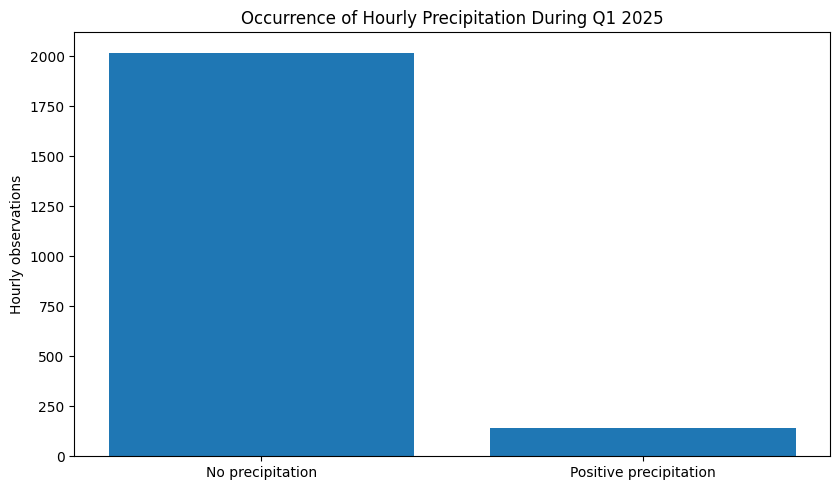

In [17]:
precipitation_occurrence = pd.Series({
    "No precipitation": weather["precipitation_in"].eq(0).sum(),
    "Positive precipitation": weather["precipitation_in"].gt(0).sum()
})

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.bar(precipitation_occurrence.index, precipitation_occurrence.values)
ax.set_ylabel("Hourly observations")
ax.set_title("Occurrence of Hourly Precipitation During Q1 2025")
plt.tight_layout()
plt.show()

In [18]:
city_hourly_demand = (
    df.groupby("pickup_hour", as_index=False)["pickup_count"]
      .sum()
      .merge(weather, on="pickup_hour", how="left", validate="one_to_one")
)

weather_correlations = pd.DataFrame({
    "Relationship": [
        "Temperature vs citywide hourly pickups",
        "Precipitation vs citywide hourly pickups"
    ],
    "Pearson correlation": [
        pearsonr(city_hourly_demand["temperature_f"], city_hourly_demand["pickup_count"])[0],
        pearsonr(city_hourly_demand["precipitation_in"], city_hourly_demand["pickup_count"])[0]
    ]
})

display(weather_correlations)

,Relationship,Pearson correlation
0,Temperature vs citywide hourly pickups,0.1940
1,Precipitation vs citywide hourly pickups,0.0984


**Interpretation:** Positive precipitation is uncommon during the study period. The simple weather correlations are weak, but they do not rule out nonlinear relationships that can be learned by tree-based models.

## 7. Contextual Taxi-Zone Characteristics

The contextual variables are examined once per taxi zone because their values remain fixed across the hourly observations belonging to the same zone.

In [19]:
zone_context = (
    df.sort_values(["LocationID", "pickup_hour"])
      .drop_duplicates("LocationID")
      [[
          "LocationID", "borough", "zone", "subway_proximity_km",
          "estimated_total_households", "estimated_zero_vehicle_households",
          "zero_vehicle_household_rate", "zero_vehicle_rate_moe",
          "zero_vehicle_rate_cv", "census_reliability", "census_coverage_ratio"
      ]]
      .merge(
          zone_summary[["LocationID", "mean_hourly_demand", "total_pickups"]],
          on="LocationID",
          how="left",
          validate="one_to_one"
      )
)

### 7.1 Subway Proximity

In [20]:
subway_statistics = zone_context["subway_proximity_km"].describe(percentiles=[0.25, 0.50, 0.75, 0.90]).to_frame("subway_proximity_km")
display(subway_statistics)

,subway_proximity_km
count,259.0000
mean,1.0714
std,1.3865
min,0.0105
25%,0.2790
50%,0.5035
75%,1.1328
90%,2.8335
max,7.5710


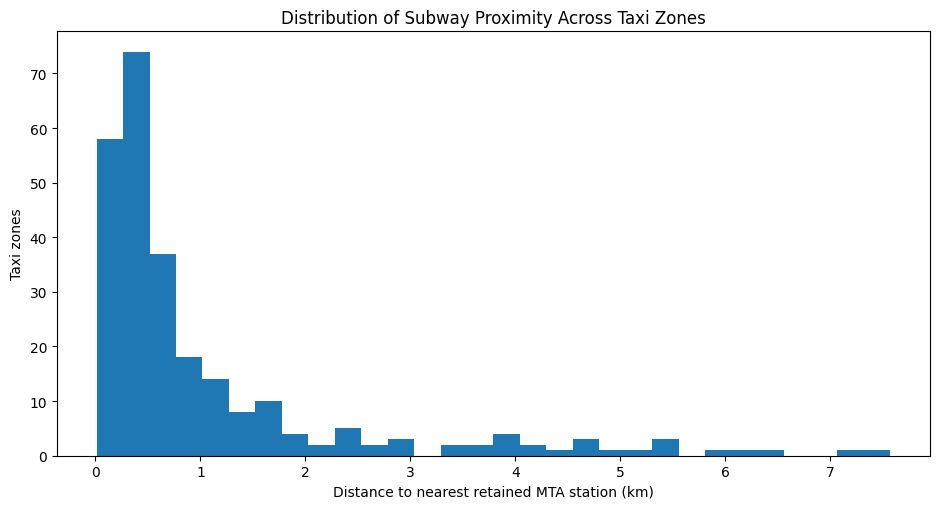

In [21]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.hist(zone_context["subway_proximity_km"], bins=30)
ax.set_xlabel("Distance to nearest retained MTA station (km)")
ax.set_ylabel("Taxi zones")
ax.set_title("Distribution of Subway Proximity Across Taxi Zones")
plt.tight_layout()
plt.show()

**Interpretation:** Most taxi zones are relatively close to a retained MTA station, while a smaller group forms a long right tail of greater station distance.

### 7.2 Zero-Vehicle Household Rate

In [22]:
zero_vehicle_statistics = (zone_context["zero_vehicle_household_rate"] * 100).describe(percentiles=[0.25, 0.50, 0.75, 0.90]).to_frame("zero_vehicle_household_rate_percent")
display(zero_vehicle_statistics)

borough_zero_vehicle = (
    zone_context.assign(zero_vehicle_household_rate_percent=zone_context["zero_vehicle_household_rate"] * 100)
                .groupby("borough")["zero_vehicle_household_rate_percent"]
                .median()
                .rename("median_zero_vehicle_household_rate_percent")
                .sort_values(ascending=False)
                .reset_index()
)
display(borough_zero_vehicle)

,zero_vehicle_household_rate_percent
count,259.0000
mean,52.5056
std,24.8213
min,4.9322
25%,30.3557
50%,60.4775
75%,73.2055
90%,81.0539
max,92.9215


,borough,median_zero_vehicle_household_rate_percent
0,Manhattan,78.8436
1,Bronx,68.0783
2,Brooklyn,60.3357
3,Queens,26.3481
4,Staten Island,12.4016


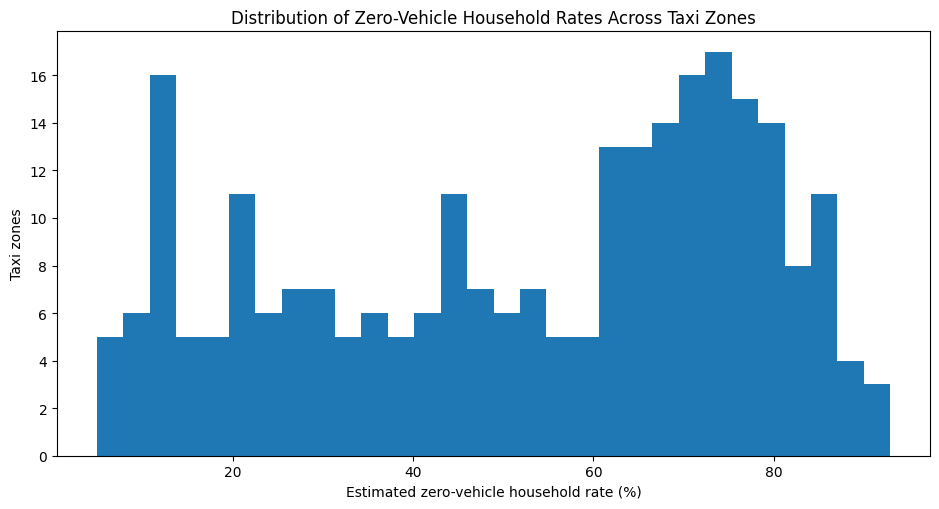

In [23]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.hist(zone_context["zero_vehicle_household_rate"] * 100, bins=30)
ax.set_xlabel("Estimated zero-vehicle household rate (%)")
ax.set_ylabel("Taxi zones")
ax.set_title("Distribution of Zero-Vehicle Household Rates Across Taxi Zones")
plt.tight_layout()
plt.show()

**Interpretation:** Household vehicle availability varies widely across the taxi zones, providing substantial spatial variation for the planned contextual experiment.

### 7.3 Contextual Features and Zone-Level Demand

In [24]:
rho_subway, p_subway = spearmanr(zone_context["subway_proximity_km"], zone_context["mean_hourly_demand"])
rho_vehicle, p_vehicle = spearmanr(zone_context["zero_vehicle_household_rate"], zone_context["mean_hourly_demand"])
rho_context, p_context = spearmanr(zone_context["subway_proximity_km"], zone_context["zero_vehicle_household_rate"])

context_correlations = pd.DataFrame({
    "Relationship": [
        "Subway proximity vs mean hourly taxi demand",
        "Zero-vehicle household rate vs mean hourly taxi demand",
        "Subway proximity vs zero-vehicle household rate"
    ],
    "Spearman rho": [rho_subway, rho_vehicle, rho_context],
    "p-value": [p_subway, p_vehicle, p_context]
})

display(context_correlations)

display(
    zone_context.sort_values("mean_hourly_demand", ascending=False)
                [["LocationID", "borough", "zone", "mean_hourly_demand", "subway_proximity_km", "zero_vehicle_household_rate"]]
                .head(10)
)

,Relationship,Spearman rho,p-value
0,Subway proximity vs mean hourly taxi demand,-0.5547,0.0000
1,Zero-vehicle household rate vs mean hourly tax...,0.6845,0.0000
2,Subway proximity vs zero-vehicle household rate,-0.6715,0.0000


,LocationID,borough,zone,mean_hourly_demand,subway_proximity_km,zero_vehicle_household_rate
156,161,Manhattan,Midtown Center,221.8509,0.3146,0.7745
232,237,Manhattan,Upper East Side South,215.8170,0.1580,0.6137
231,236,Manhattan,Upper East Side North,199.4317,0.1594,0.6146
127,132,Queens,JFK Airport,175.1941,3.9936,0.1413
225,230,Manhattan,Times Sq/Theatre District,160.0824,0.0105,0.9292
181,186,Manhattan,Penn Station/Madison Sq West,158.8513,0.1625,0.9130
157,162,Manhattan,Midtown East,156.7314,0.0594,0.8618
137,142,Manhattan,Lincoln Square East,144.0750,0.0610,0.7465
229,234,Manhattan,Union Sq,134.4044,0.1427,0.8187
165,170,Manhattan,Murray Hill,129.5929,0.3547,0.8871


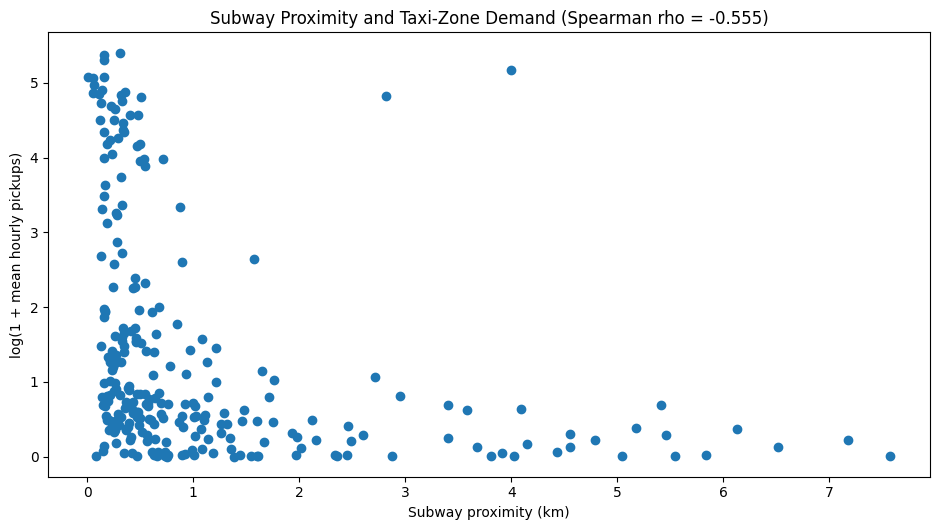

In [25]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.scatter(zone_context["subway_proximity_km"], np.log1p(zone_context["mean_hourly_demand"]))
ax.set_xlabel("Subway proximity (km)")
ax.set_ylabel("log(1 + mean hourly pickups)")
ax.set_title(f"Subway Proximity and Taxi-Zone Demand (Spearman rho = {rho_subway:.3f})")
plt.tight_layout()
plt.show()

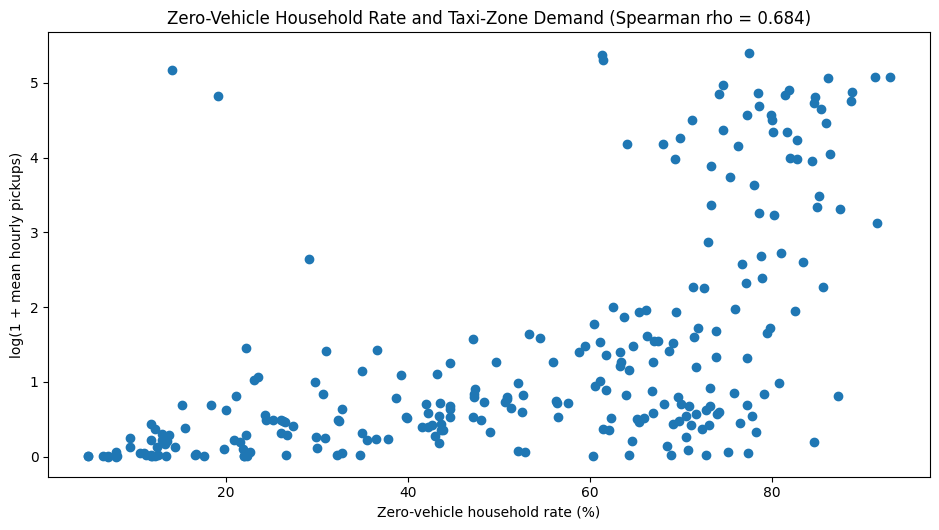

In [26]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.scatter(zone_context["zero_vehicle_household_rate"] * 100, np.log1p(zone_context["mean_hourly_demand"]))
ax.set_xlabel("Zero-vehicle household rate (%)")
ax.set_ylabel("log(1 + mean hourly pickups)")
ax.set_title(f"Zero-Vehicle Household Rate and Taxi-Zone Demand (Spearman rho = {rho_vehicle:.3f})")
plt.tight_layout()
plt.show()

**Interpretation:** Both contextual variables show meaningful rank relationships with zone-level demand, but the scatterplots also contain clear exceptions. Their predictive contribution must therefore be tested through the controlled model experiments rather than inferred from correlation alone.

## 8. Census Feature Reliability

In [27]:
reliability_order = ["high", "moderate", "low"]

reliability_summary = (
    zone_context["census_reliability"]
      .value_counts()
      .reindex(reliability_order, fill_value=0)
      .rename_axis("reliability")
      .reset_index(name="taxi_zones")
)
reliability_summary["percentage"] = reliability_summary["taxi_zones"] / len(zone_context) * 100

display(reliability_summary)

coverage_statistics = zone_context["census_coverage_ratio"].describe().to_frame("census_coverage_ratio")
display(coverage_statistics)

low_reliability_zones = (
    zone_context.loc[zone_context["census_reliability"].eq("low"), [
        "LocationID", "borough", "zone", "estimated_total_households",
        "zero_vehicle_household_rate", "zero_vehicle_rate_moe",
        "zero_vehicle_rate_cv", "census_coverage_ratio"
    ]]
    .sort_values("zero_vehicle_rate_cv", ascending=False)
)
display(low_reliability_zones)

,reliability,taxi_zones,percentage
0,high,208,80.3089
1,moderate,38,14.6718
2,low,13,5.0193


,census_coverage_ratio
count,259.0000
mean,0.9998
std,0.0012
min,0.9878
25%,1.0000
50%,1.0000
75%,1.0000
max,1.0000


,LocationID,borough,zone,estimated_total_households,zero_vehicle_household_rate,zero_vehicle_rate_moe,zero_vehicle_rate_cv,census_coverage_ratio
194,199,Bronx,Rikers Island,0.0779,0.2205,175.0999,482.7217,1.0000
105,110,Staten Island,Great Kills Park,3.3609,0.0709,4.1328,35.4351,1.0000
123,128,Manhattan,Inwood Hill Park,0.6252,0.5283,18.6733,21.4892,1.0000
6,8,Queens,Astoria Park,0.4995,0.6424,21.4766,20.3239,1.0000
106,111,Brooklyn,Green-Wood Cemetery,0.9995,0.6034,11.1616,11.2467,1.0000
97,99,Staten Island,Freshkills Park,24.4142,0.0494,0.8069,9.9366,1.0000
149,154,Brooklyn,Marine Park/Floyd Bennett Field,17.3990,0.0793,1.1345,8.6959,1.0000
0,2,Queens,Jamaica Bay,17.7722,0.1186,1.1062,5.6696,1.0000
127,132,Queens,JFK Airport,25.5770,0.1413,0.5414,2.3295,1.0000
248,253,Queens,Willets Point,7.2735,0.6891,1.3866,1.2234,1.0000


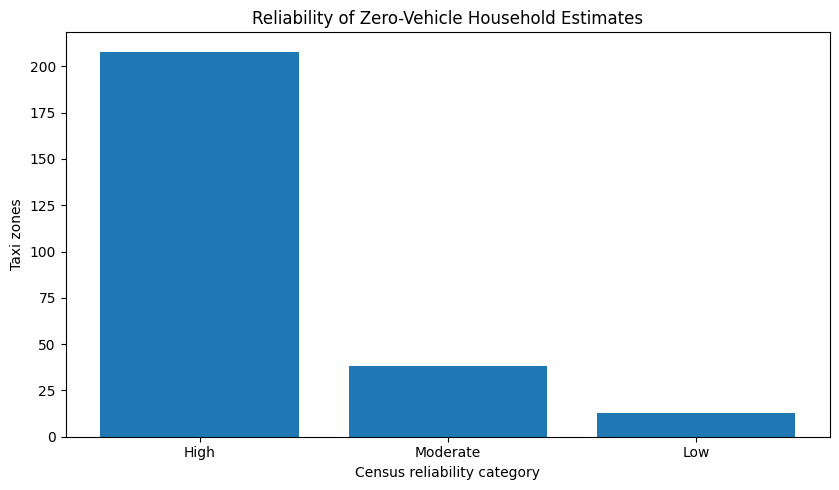

In [28]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.bar(reliability_summary["reliability"].str.title(), reliability_summary["taxi_zones"])
ax.set_xlabel("Census reliability category")
ax.set_ylabel("Taxi zones")
ax.set_title("Reliability of Zero-Vehicle Household Estimates")
plt.tight_layout()
plt.show()

**Interpretation:** Most taxi-zone estimates fall in the high-reliability category, while the low-reliability cases are concentrated in a small group that can be retained for quality interpretation without adding the uncertainty measures as predictors.

## 9. Repeated Taxi-Zone Structure

In [29]:
repeated_zone_check = (
    df.groupby("LocationID")
      .agg(
          rows=("pickup_hour", "size"),
          unique_hours=("pickup_hour", "nunique"),
          unique_subway_values=("subway_proximity_km", "nunique"),
          unique_zero_vehicle_rates=("zero_vehicle_household_rate", "nunique")
      )
)

repeated_structure_summary = pd.DataFrame({
    "Check": [
        "Rows per LocationID - minimum",
        "Rows per LocationID - maximum",
        "Unique hours per LocationID - minimum",
        "Unique hours per LocationID - maximum",
        "Unique subway values within each zone - maximum",
        "Unique zero-vehicle rates within each zone - maximum",
        "Distinct subway values across zones",
        "Distinct zero-vehicle rates across zones"
    ],
    "Result": [
        repeated_zone_check["rows"].min(),
        repeated_zone_check["rows"].max(),
        repeated_zone_check["unique_hours"].min(),
        repeated_zone_check["unique_hours"].max(),
        repeated_zone_check["unique_subway_values"].max(),
        repeated_zone_check["unique_zero_vehicle_rates"].max(),
        zone_context["subway_proximity_km"].nunique(),
        zone_context["zero_vehicle_household_rate"].nunique()
    ]
})

display(repeated_structure_summary)

,Check,Result
0,Rows per LocationID - minimum,2159
1,Rows per LocationID - maximum,2159
2,Unique hours per LocationID - minimum,2159
3,Unique hours per LocationID - maximum,2159
4,Unique subway values within each zone - maximum,1
5,Unique zero-vehicle rates within each zone - m...,1
6,Distinct subway values across zones,259
7,Distinct zero-vehicle rates across zones,259


**Interpretation:** Every taxi zone is observed repeatedly through time, while the two contextual variables remain fixed within a zone. `LocationID` is therefore retained for grouping and zone-level evaluation rather than included in the primary predictor matrix.

## 10. Definition of Low-Demand Outer-Borough Zones

In [30]:
all_hours = np.sort(df["pickup_hour"].unique())

development_hour_count = int(np.floor(len(all_hours) * 0.80))
training_hour_count = int(np.floor(development_hour_count * 0.80))
validation_hour_count = development_hour_count - training_hour_count
final_test_hour_count = len(all_hours) - development_hour_count

training_hours = all_hours[:training_hour_count]
validation_hours = all_hours[training_hour_count:development_hour_count]
final_test_hours = all_hours[development_hour_count:]

split_summary = pd.DataFrame({
    "Partition": ["Training", "Validation", "Final test"],
    "Hours": [training_hour_count, validation_hour_count, final_test_hour_count],
    "Start": [training_hours.min(), validation_hours.min(), final_test_hours.min()],
    "End": [training_hours.max(), validation_hours.max(), final_test_hours.max()]
})

display(split_summary)

training_zone_demand = (
    df.loc[df["pickup_hour"].isin(training_hours)]
      .groupby(["LocationID", "borough", "zone"], as_index=False)["pickup_count"]
      .mean()
      .rename(columns={"pickup_count": "training_mean_demand"})
)

low_demand_threshold = training_zone_demand["training_mean_demand"].quantile(0.25)
training_zone_demand["demand_group"] = np.where(
    training_zone_demand["training_mean_demand"] <= low_demand_threshold,
    "Low demand",
    "Other"
)

outer_boroughs = ["Bronx", "Brooklyn", "Queens", "Staten Island"]
low_demand_zones = training_zone_demand.loc[training_zone_demand["demand_group"].eq("Low demand")].copy()
low_demand_outer = low_demand_zones.loc[low_demand_zones["borough"].isin(outer_boroughs)].copy()

low_demand_summary = pd.DataFrame({
    "Measure": [
        "First-quartile threshold",
        "Low-demand zones - all boroughs",
        "Low-demand outer-borough zones",
        "Median training mean demand in low-demand group",
        "Maximum training mean demand in low-demand group"
    ],
    "Value": [
        low_demand_threshold,
        len(low_demand_zones),
        len(low_demand_outer),
        low_demand_zones["training_mean_demand"].median(),
        low_demand_zones["training_mean_demand"].max()
    ]
})

display(low_demand_summary)

low_demand_by_borough = (
    low_demand_outer.groupby("borough")
                    .size()
                    .reindex(outer_boroughs, fill_value=0)
                    .rename("low_demand_zones")
                    .reset_index()
)

display(low_demand_by_borough)
display(low_demand_outer.sort_values(["borough", "training_mean_demand", "LocationID"]))

,Partition,Hours,Start,End
0,Training,1381,2025-01-01 00:00:00,2025-02-27 12:00:00
1,Validation,346,2025-02-27 13:00:00,2025-03-13 23:00:00
2,Final test,432,2025-03-14 00:00:00,2025-03-31 23:00:00


,Measure,Value
0,First-quartile threshold,0.3070
1,Low-demand zones - all boroughs,65.0000
2,Low-demand outer-borough zones,60.0000
3,Median training mean demand in low-demand group,0.0406
4,Maximum training mean demand in low-demand group,0.3041


,borough,low_demand_zones
0,Bronx,11
1,Brooklyn,7
2,Queens,22
3,Staten Island,20


,LocationID,borough,zone,training_mean_demand,demand_group
194,199,Bronx,Rikers Island,0.0014,Low demand
57,59,Bronx,Crotona Park,0.0159,Low demand
179,184,Bronx,Pelham Bay Park,0.0188,Low demand
44,46,Bronx,City Island,0.0304,Low demand
56,58,Bronx,Country Club,0.0319,Low demand
29,31,Bronx,Bronx Park,0.0398,Low demand
235,240,Bronx,Van Cortlandt Park,0.0608,Low demand
178,183,Bronx,Pelham Bay,0.1470,Low demand
195,200,Bronx,Riverdale/North Riverdale/Fieldston,0.2317,Low demand
1,3,Bronx,Allerton/Pelham Gardens,0.2440,Low demand


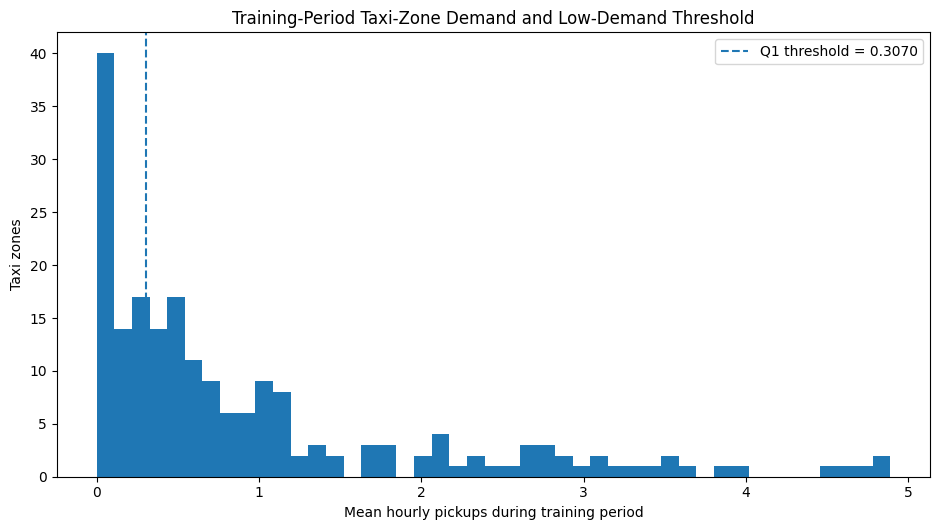

In [31]:
focus_demand = training_zone_demand.loc[
    training_zone_demand["training_mean_demand"] <= 5,
    "training_mean_demand"
]

fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.hist(focus_demand, bins=45)
ax.axvline(low_demand_threshold, linestyle="--", label=f"Q1 threshold = {low_demand_threshold:.4f}")
ax.set_xlabel("Mean hourly pickups during training period")
ax.set_ylabel("Taxi zones")
ax.set_title("Training-Period Taxi-Zone Demand and Low-Demand Threshold")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The low-demand group is defined before model evaluation using only the training period. The first-quartile threshold therefore produces a fixed outer-borough subset for the later contextual-feature comparison.

## 11. Predictor Selection for Model Building

The Data Understanding results lead to the following modelling roles:

- **Target:** `pickup_count`
- **Baseline predictors:** `hour`, `day_of_week`, `month`, `temperature_f`, `precipitation_in`
- **Contextual enrichment:** `subway_proximity_km`, `zero_vehicle_household_rate`
- **Evaluation and grouping:** `LocationID`, `borough`, `zone`, `pickup_hour`
- **Census quality checks:** `zero_vehicle_rate_moe`, `zero_vehicle_rate_cv`, `census_reliability`, `census_coverage_ratio`

`LocationID` is not included in the primary predictor matrix. The two contextual variables are kept separate from the baseline so that their contribution can be tested individually and together during model building.

In [32]:
target = "pickup_count"

baseline_features = [
    "hour",
    "day_of_week",
    "month",
    "temperature_f",
    "precipitation_in"
]

contextual_features = [
    "subway_proximity_km",
    "zero_vehicle_household_rate"
]

model_feature_sets = {
    "Baseline": baseline_features,
    "Baseline + Subway": baseline_features + ["subway_proximity_km"],
    "Baseline + Zero-Vehicle Rate": baseline_features + ["zero_vehicle_household_rate"],
    "Baseline + Both": baseline_features + contextual_features
}

model_feature_sets

{'Baseline': ['hour',
  'day_of_week',
  'month',
  'temperature_f',
  'precipitation_in'],
 'Baseline + Subway': ['hour',
  'day_of_week',
  'month',
  'temperature_f',
  'precipitation_in',
  'subway_proximity_km'],
 'Baseline + Zero-Vehicle Rate': ['hour',
  'day_of_week',
  'month',
  'temperature_f',
  'precipitation_in',
  'zero_vehicle_household_rate'],
 'Baseline + Both': ['hour',
  'day_of_week',
  'month',
  'temperature_f',
  'precipitation_in',
  'subway_proximity_km',
  'zero_vehicle_household_rate']}